In [39]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

In [40]:
data = np.load('../solutions/transient.npy')
time, flux, fluxerr = data.T

<ErrorbarContainer object of 3 artists>

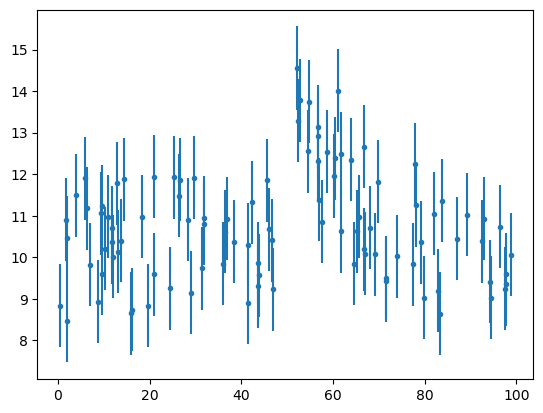

In [41]:
plt.errorbar(time, flux, fluxerr, fmt = '.')

In [42]:
def model(theta, t):
    A, b, alpha, t_0 = theta
    y = np.ones_like(t)*b
    mask = np.where(t >= t_0)
    y[mask] += A*np.exp(-alpha*(t[mask]-t_0))
    return y

$p(x)dx = p(y)dy \quad \rightarrow \quad p(log(\alpha))=p(\alpha)/\alpha$

In [43]:
def log_prior(theta):
    A, b, alpha, t_0 = theta
    if 0.0 < b < 50. and 0.0 < A < 50.0 and 0.0 < t_0 < 100.0 and -5.0 < np.log(alpha) < 5.0:
        return 0.0 - np.log(alpha)
    return -np.inf

In [44]:
def log_likelihood(theta, t, f, errf):
    y = model(theta,t)
    leastsq = ((y-f)/errf)**2
    return -1/2*np.sum(leastsq)

In [45]:
def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

In [ ]:
ndim = 4  # number of parameters in the model
nwalkers = 20  # number of MCMC walkers
burn = 1000  # "burn-in" period to let chains stabilize
nsteps = 100000
guesses = np.array([25.,25.,1., 50.])+np.random.random((nwalkers, ndim))*1e-1
#guesses = theta_quick+np.random.random((nwalkers, ndim))*1e-1
#starting_guesses = np.random.random((nwalkers, ndim))

In [52]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=[time, flux, fluxerr])
_ = sampler.run_mcmc(guesses, nsteps)

/var/folders/_h/ldjx52094bd50nf5x0f85ybr0000gn/T/ipykernel_72460/39041966.py:3: RuntimeWarning: invalid value encountered in log
  if 0.0 < b < 50. and 0.0 < A < 50.0 and 0.0 < t_0 < 100.0 and -5.0 < np.log(alpha) < 5.0:


In [53]:
tau = sampler.get_autocorr_time()
print(tau)

[633.85597547 115.09835447 837.57505738 199.92058029]


In [54]:
samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True)

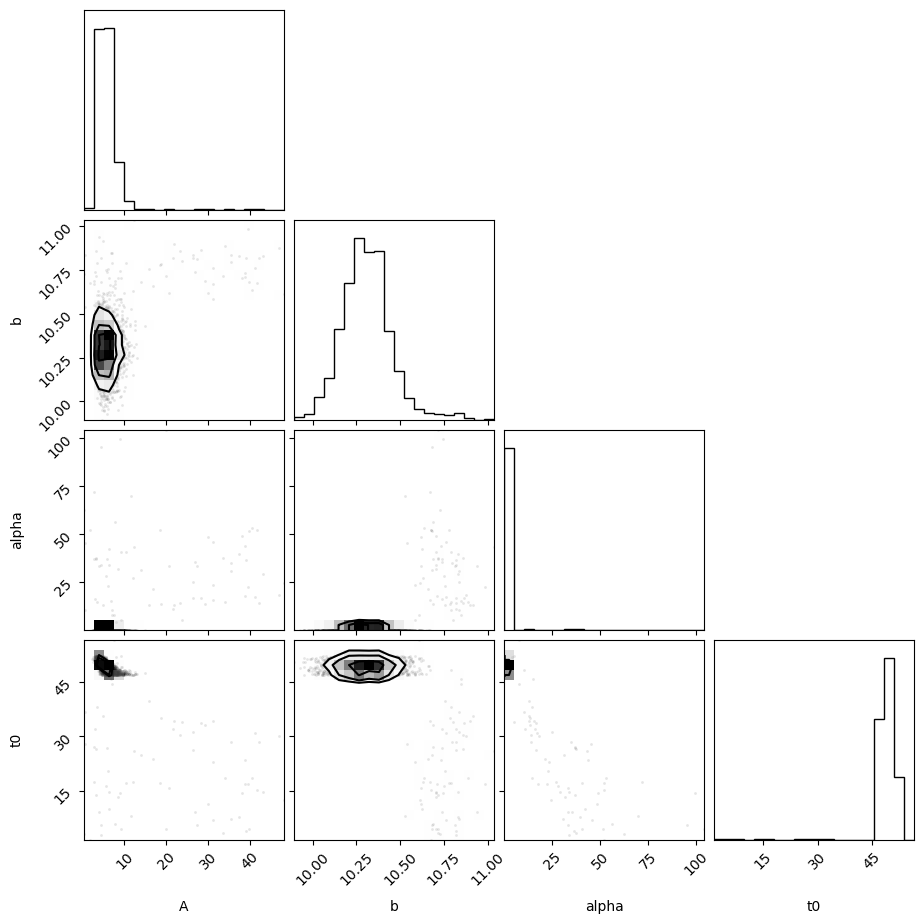

In [55]:
labels = ["A","b","alpha","t0"]
fig = corner.corner(samples, labels = labels)

In [56]:
ndim = 4  # number of parameters in the model
nwalkers = 20  # number of MCMC walkers
burn = 1000  # "burn-in" period to let chains stabilize
nsteps = 100000
guesses = np.array([10.,10.,1., 50.])+np.random.random((nwalkers, ndim))*1e-1
#guesses = theta_quick+np.random.random((nwalkers, ndim))*1e-1
#starting_guesses = np.random.random((nwalkers, ndim))

In [57]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=[time, flux, fluxerr])
_ = sampler.run_mcmc(guesses, nsteps)

/var/folders/_h/ldjx52094bd50nf5x0f85ybr0000gn/T/ipykernel_72460/39041966.py:3: RuntimeWarning: invalid value encountered in log
  if 0.0 < b < 50. and 0.0 < A < 50.0 and 0.0 < t_0 < 100.0 and -5.0 < np.log(alpha) < 5.0:


In [58]:
tau = sampler.get_autocorr_time()
print(tau)

[83.05565354 61.23530951 74.01294523 81.71193194]


In [59]:
samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True)

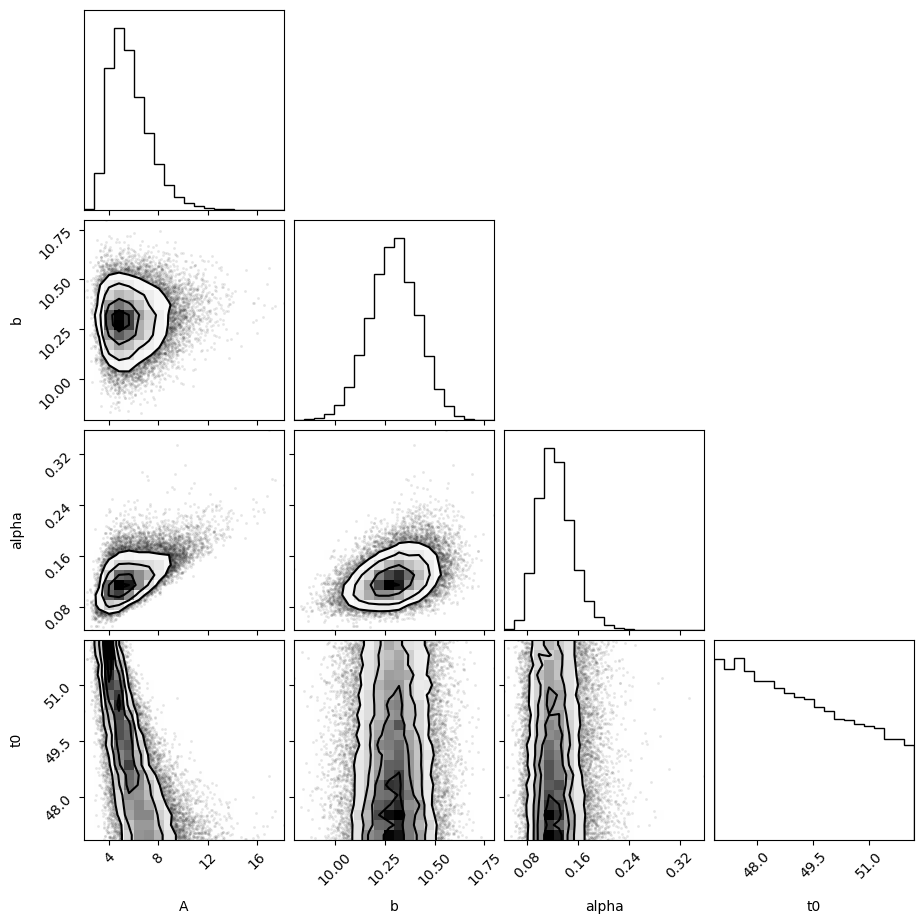

In [60]:
labels = ["A","b","alpha","t0"]
fig = corner.corner(samples, labels = labels)

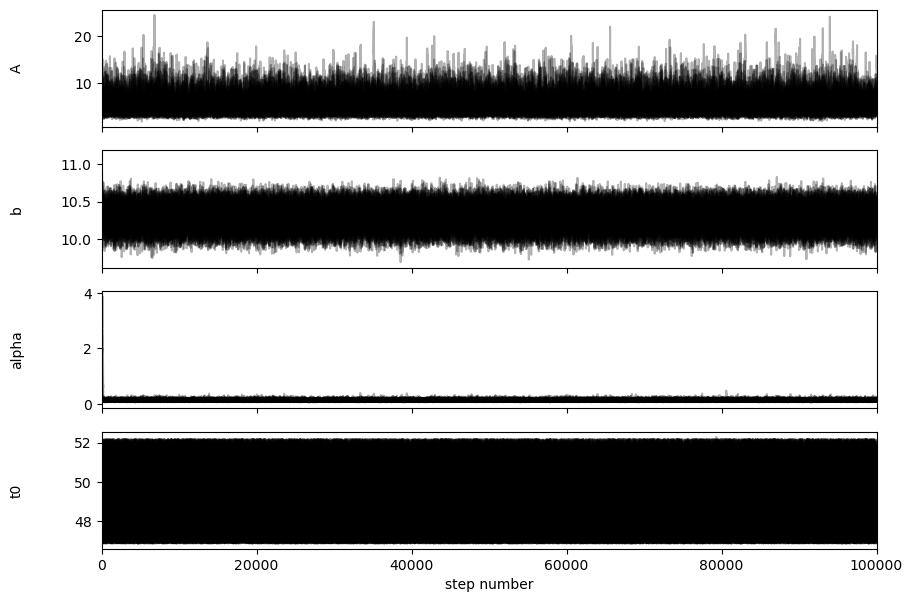

In [61]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");